Euclidean prediction: 0
Manhattan prediction: 0


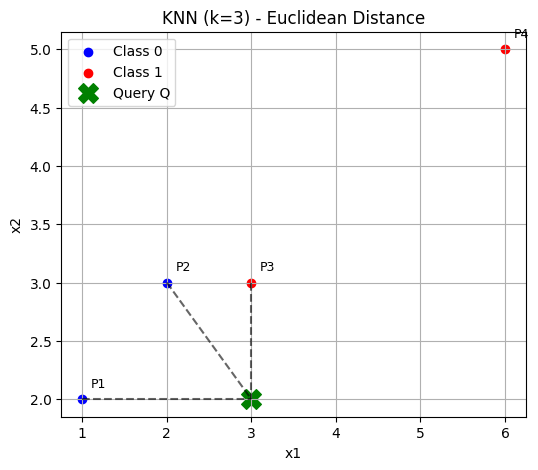

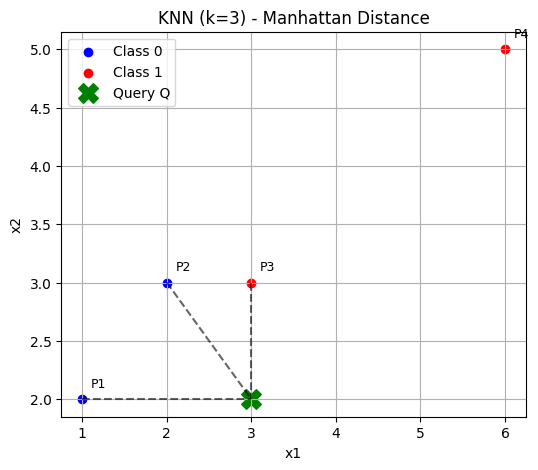

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
# Dataset
X = np.array([
   [1, 2],  # P1 - Class 0
   [2, 3],  # P2 - Class 0
   [3, 3],  # P3 - Class 1
   [6, 5],  # P4 - Class 1
])
y = np.array([0, 0, 1, 1])
# Query Point
query = np.array([[3, 2]])
# --- KNN Classifier with Euclidean distance ---
knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_euclidean.fit(X, y)
pred_euc = knn_euclidean.predict(query)
dist_euc, idx_euc = knn_euclidean.kneighbors(query)
# --- KNN Classifier with Manhattan distance ---
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X, y)
pred_man = knn_manhattan.predict(query)
dist_man, idx_man = knn_manhattan.kneighbors(query)
print("Euclidean prediction:", pred_euc[0])
print("Manhattan prediction:", pred_man[0])
# --- Plotting ---
def plot_knn(X, y, query, neighbors_idx, title):
   plt.figure(figsize=(6, 5))
   # Plot data points
   for i in range(len(X)):
       plt.scatter(X[i][0], X[i][1], c='blue' if y[i]==0 else 'red', label=f'Class {y[i]}' if i==0 or i==2 else "")
       plt.text(X[i][0]+0.1, X[i][1]+0.1, f'P{i+1}', fontsize=9)
   # Plot query point
   plt.scatter(query[0][0], query[0][1], c='green', marker='X', s=200, label='Query Q')
   # Draw lines to nearest neighbors
   for idx in neighbors_idx[0]:
       plt.plot([X[idx][0], query[0][0]], [X[idx][1], query[0][1]], 'k--', alpha=0.6)
   plt.title(title)
   plt.xlabel("x1")
   plt.ylabel("x2")
   plt.legend()
   plt.grid(True)
   plt.show()
# Plot for Euclidean
plot_knn(X, y, query, idx_euc, title="KNN (k=3) - Euclidean Distance")
# Plot for Manhattan
plot_knn(X, y, query, idx_man, title="KNN (k=3) - Manhattan Distance")